In [1]:
from pathlib import Path
import sys

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import FEATURES
from src.training import create_candidates, compare_classifiers


DATA = PROJECT_ROOT / "data" / "processed"
MODELS = PROJECT_ROOT / "models"
REPORTS = PROJECT_ROOT / "reports"

for folder in [MODELS, REPORTS / "metrics", REPORTS / "figures"]:
    folder.mkdir(parents=True, exist_ok=True)

train_data = pd.read_csv(
    DATA / "train_labeled.csv",
    index_col="source_row",
)

X_train = train_data[FEATURES].copy()
y_train = train_data["Cluster"].copy()

assert y_train.notna().all()

print("Input shape:", X_train.shape)
print("Target shape:", y_train.shape)

Input shape: (614, 7)
Target shape: (614,)


In [2]:
class_counts = y_train.value_counts().sort_index()

display(
    pd.DataFrame({
        "patients": class_counts,
        "percentage": class_counts / len(y_train) * 100,
    }).round(2)
)

if len(class_counts) < 2:
    raise ValueError("Classification requires at least two classes.")

n_splits = min(5, int(class_counts.min()))

if n_splits < 2:
    raise ValueError(
        "A cluster has fewer than two patients. "
        "Review the clustering before cross-validation."
    )

cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42,
)

folds = list(cv.split(X_train, y_train))

print("Number of validation folds:", n_splits)

,patients,percentage
Cluster,,
0,149,24.27
1,266,43.32
2,33,5.37
3,166,27.04


Number of validation folds: 5


In [3]:
candidates = create_candidates()

results = compare_classifiers(
    candidates,
    X_train,
    y_train,
    folds,
)

display(results.round(3))

results.to_csv(
    REPORTS / "metrics" / "classification_baselines.csv",
    index=False,
)

Evaluating: Logistic Regression | no sampling
Evaluating: Logistic Regression | oversampling
Evaluating: Random Forest | no sampling
Evaluating: Random Forest | oversampling
Evaluating: SVC | no sampling
Evaluating: SVC | oversampling


,Model,Train_F1,CV_F1,CV_F1_std,CV_Precision,CV_Recall,CV_Accuracy
0,Logistic Regression | oversampling,0.981,0.975,0.011,0.967,0.985,0.979
1,Logistic Regression | no sampling,0.990,0.965,0.014,0.968,0.964,0.971
2,SVC | no sampling,0.987,0.954,0.028,0.958,0.952,0.961
3,SVC | oversampling,0.979,0.954,0.012,0.951,0.960,0.958
4,Random Forest | oversampling,1.000,0.936,0.019,0.942,0.934,0.935
5,Random Forest | no sampling,1.000,0.936,0.023,0.949,0.928,0.935


loading baseline: Logistic Regression | oversampling
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       149
           1       0.99      0.97      0.98       266
           2       0.92      1.00      0.96        33
           3       0.97      0.99      0.98       166

    accuracy                           0.98       614
   macro avg       0.97      0.99      0.97       614
weighted avg       0.98      0.98      0.98       614



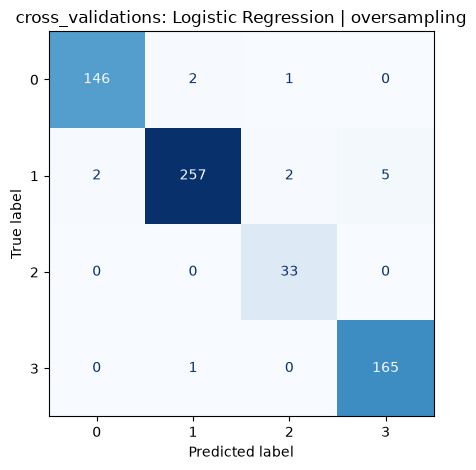

In [4]:
# ???

best_name = results.loc[0, "Model"]
best_candidate = candidates[best_name]

print("loading baseline:", best_name)

validation_predictions = cross_val_predict(
    best_candidate,
    X_train,
    y_train,
    cv=folds,
    n_jobs=1
)

print(
    classification_report(
        y_train,
        validation_predictions,
        zero_division=0,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    validation_predictions,
    cmap="Blues",
    colorbar=False,
)

plt.title(f"cross_validations: {best_name}")
plt.tight_layout()

plt.savefig(
    REPORTS / "figures" / "baseline_confusion_matrix.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [5]:
baseline_pipeline = clone(best_candidate)

baseline_pipeline.fit(X_train, y_train)

clustering_bundle = joblib.load(
    MODELS / "clustering_bundle.joblib"
)

# Confirm these labels belong to the saved clustering model.
reference_labels = clustering_bundle["pipeline"].predict(X_train)

if not (reference_labels == y_train.to_numpy()).all():
    raise ValueError(
        "Training labels do not match the clustering bundle. "
        "Regenerate labeled data with the intended clustering model."   
    )

baseline_bundle = {
    "pipeline": baseline_pipeline,
    "model_name": best_name,
    "features": FEATURES,
    "risk_mapping": clustering_bundle["risk_mapping"],
    "selected_k": clustering_bundle["selected_k"],
    "cv_f1": float(results.loc[0, "CV_F1"]),
    "status": "baseline_before_tuning",
}

joblib.dump(
    baseline_bundle,
    MODELS / "classification_baseline.joblib",
)

print("Baseline classifier saved.")

Baseline classifier saved.
